In [1]:
import os

# Lister TOUT ce qui est disponible dans /kaggle/input/
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/bakagnan/give-me-credit/cs-training.csv


# Prédiction de défaut de crédit — Pipeline ML bout-en-bout

## Contexte métier
Une banque souhaite prédire si un client remboursera son prêt.
Dataset : Give Me Some Credit (150 000 clients, 11 variables financières).

## Pipeline
EDA → Preprocessing → Modélisation → Interprétabilité SHAP

In [2]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120


In [3]:
# ============================================================
# CHARGEMENT DES DONNÉES
# ============================================================
PATH = "/kaggle/input/datasets/bakagnan/give-me-credit/cs-training.csv"
df = pd.read_csv(PATH, index_col=0)

print("=" * 50)
print(f"Shape      : {df.shape}")
print(f"Lignes     : {df.shape[0]:}")
print(f"Colonnes   : {df.shape[1]}")
print("=" * 50)
display(df.head(3))
display(df.describe().T.round(2))

Shape      : (150000, 11)
Lignes     : 150000
Colonnes   : 11


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.07,0.25,0.0,0.00,0.00,0.00,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.05,249.76,0.0,0.03,0.15,0.56,50708.0
age,150000.0,52.30,14.77,0.0,41.00,52.00,63.00,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.42,4.19,0.0,0.00,0.00,0.00,98.0
DebtRatio,150000.0,353.01,2037.82,0.0,0.18,0.37,0.87,329664.0
MonthlyIncome,120269.0,6670.22,14384.67,0.0,3400.00,5400.00,8249.00,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.45,5.15,0.0,5.00,8.00,11.00,58.0
NumberOfTimes90DaysLate,150000.0,0.27,4.17,0.0,0.00,0.00,0.00,98.0
NumberRealEstateLoansOrLines,150000.0,1.02,1.13,0.0,0.00,1.00,2.00,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.24,4.16,0.0,0.00,0.00,0.00,98.0


Classe 0 (pas de défaut) : 139,974  (93.3%)
Classe 1 (défaut)        :  10,026  (6.7%)
Ratio déséquilibre       : 1 : 14


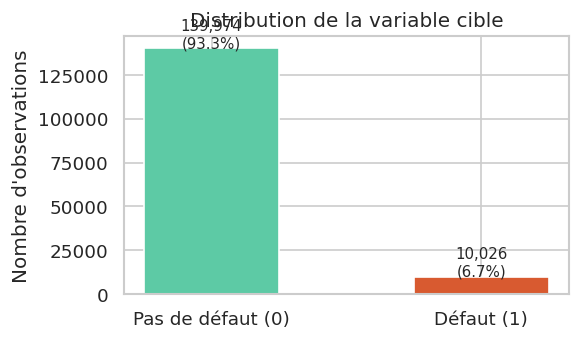

In [4]:
# ============================================================
# ÉTAPE 1 — VARIABLE CIBLE & DÉSÉQUILIBRE
# ============================================================
TARGET = "SeriousDlqin2yrs"
counts = df[TARGET].value_counts()
ratio  = df[TARGET].value_counts(normalize=True) * 100

print(f"Classe 0 (pas de défaut) : {counts[0]:>7,}  ({ratio[0]:.1f}%)")
print(f"Classe 1 (défaut)        : {counts[1]:>7,}  ({ratio[1]:.1f}%)")
print(f"Ratio déséquilibre       : 1 : {counts[0]/counts[1]:.0f}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["Pas de défaut (0)", "Défaut (1)"],
       [counts[0], counts[1]],
       color=["#5DCAA5", "#D85A30"], width=0.5, edgecolor="white")
ax.set_title("Distribution de la variable cible")
ax.set_ylabel("Nombre d'observations")
for i, v in enumerate([counts[0], counts[1]]):
    ax.text(i, v + 500, f"{v:,}\n({ratio[i]:.1f}%)",
            ha="center", fontsize=9)
plt.tight_layout()
plt.show()

Colonnes avec valeurs manquantes :


,nb_manquants,pct_manquants
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


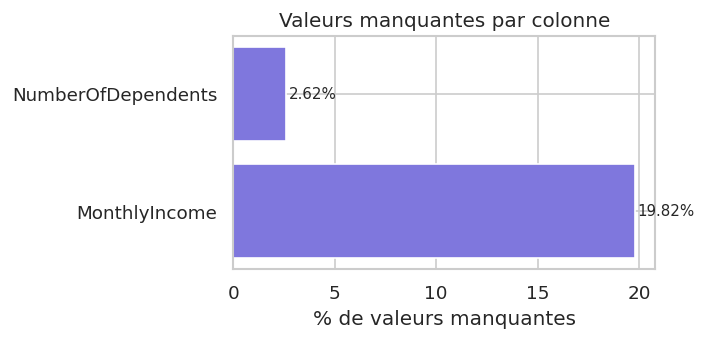

In [5]:
# ============================================================
# ÉTAPE 1 — VALEURS MANQUANTES
# ============================================================
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "nb_manquants" : missing,
    "pct_manquants": missing_pct
}).query("nb_manquants > 0").sort_values("pct_manquants", ascending=False)

print("Colonnes avec valeurs manquantes :")
display(missing_df)

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(missing_df.index, missing_df["pct_manquants"], color="#7F77DD")
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Valeurs manquantes par colonne")
for i, v in enumerate(missing_df["pct_manquants"]):
    ax.text(v + 0.1, i, f"{v}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

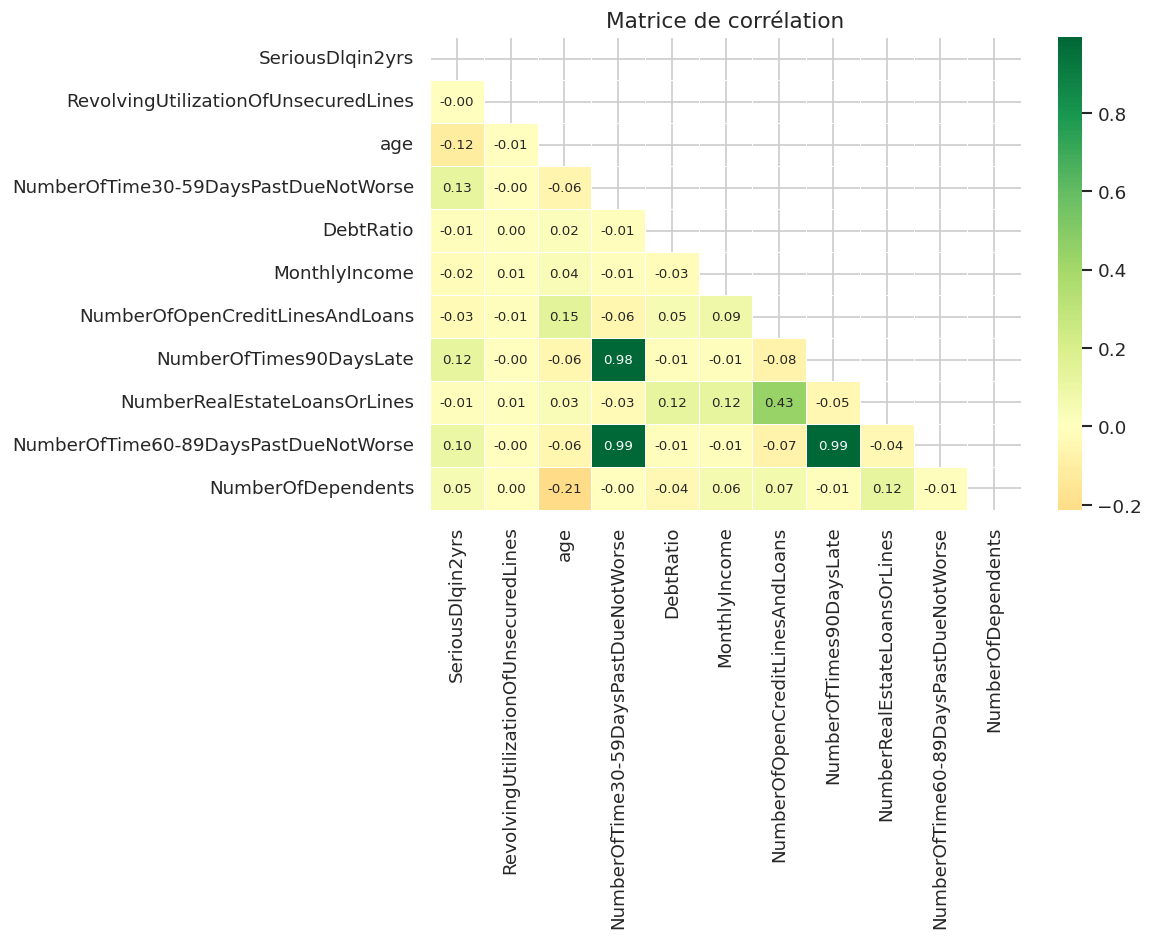


Corrélations avec la variable cible :


,SeriousDlqin2yrs
NumberOfTime30-59DaysPastDueNotWorse,0.126
NumberOfTimes90DaysLate,0.117
age,-0.115
NumberOfTime60-89DaysPastDueNotWorse,0.102
NumberOfDependents,0.046
NumberOfOpenCreditLinesAndLoans,-0.030
MonthlyIncome,-0.020
DebtRatio,-0.008
NumberRealEstateLoansOrLines,-0.007
RevolvingUtilizationOfUnsecuredLines,-0.002


In [6]:
# ============================================================
# ÉTAPE 1 — CORRÉLATIONS
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(df.corr(numeric_only=True), dtype=bool))
sns.heatmap(
    df.corr(numeric_only=True),
    mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, linewidths=0.5,
    ax=ax, annot_kws={"size": 8}
)
ax.set_title("Matrice de corrélation", fontsize=13)
plt.tight_layout()
plt.show()

# Corrélations avec la cible
corr_target = (
    df.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)
print("\nCorrélations avec la variable cible :")
display(corr_target.to_frame().round(3))

In [7]:
# ============================================================
# ÉTAPE 2 — PREPROCESSING PIPELINE
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin

# Split
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {X_train.shape} | Taux défaut : {y_train.mean():.4f}")
print(f"Test  : {X_test.shape}  | Taux défaut : {y_test.mean():.4f}")

# Transformer custom
class WinsorizationTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, lower_q=0.01, upper_q=0.99):
        self.lower_q = lower_q
        self.upper_q = upper_q
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.lower_bounds_ = X.quantile(self.lower_q)
        self.upper_bounds_ = X.quantile(self.upper_q)
        return self
    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for i, col in enumerate(X.columns):
            X[col] = X[col].clip(
                lower=self.lower_bounds_.iloc[i],
                upper=self.upper_bounds_.iloc[i]
            )
        return X.values
    def get_feature_names_out(self, input_features=None):
        return input_features

# Pipeline
feature_names = X_train.columns.tolist()
numeric_pipeline = Pipeline(steps=[
    ("winsorize", WinsorizationTransformer()),
    ("imputer",   SimpleImputer(strategy="median")),
    ("scaler",    RobustScaler()),
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, feature_names),
], remainder="drop")

# Fit sur train, transform sur test
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"\nNaN après preprocessing (train) : {np.isnan(X_train_proc).sum()}")
print(f"NaN après preprocessing (test)  : {np.isnan(X_test_proc).sum()}")
print("Pipeline OK — aucun data leakage")

Train : (120000, 10) | Taux défaut : 0.0668
Test  : (30000, 10)  | Taux défaut : 0.0668

NaN après preprocessing (train) : 0
NaN après preprocessing (test)  : 0
Pipeline OK — aucun data leakage


In [8]:
# ============================================================
# ÉTAPE 3 — MODÉLISATION & CROSS-VALIDATION
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, average_precision_score

# Définition des modèles
models = {
    "LogisticRegression": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced", max_iter=1000,
            random_state=42, solver="lbfgs"
        ))
    ]),
    "RandomForest": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100, class_weight="balanced",
            random_state=42, n_jobs=-1
        ))
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200, learning_rate=0.05,
            max_depth=4,
            scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
            eval_metric="auc", random_state=42,
            n_jobs=-1, verbosity=0
        ))
    ]),
}

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc" : "average_precision",
    "recall" : "recall",
    "f1"     : "f1",
}

cv_results = {}
print("Cross-validation en cours...\n")
for name, pipeline in models.items():
    print(f"  Fitting {name}...", end=" ")
    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    cv_results[name] = scores
    print(f"ROC-AUC = {scores['test_roc_auc'].mean():.4f} "
          f"(+/- {scores['test_roc_auc'].std():.4f})")

# Tableau comparatif
rows = []
for name, scores in cv_results.items():
    rows.append({
        "Modèle"  : name,
        "ROC-AUC" : f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        "PR-AUC"  : f"{scores['test_pr_auc'].mean():.4f} ± {scores['test_pr_auc'].std():.4f}",
        "Recall"  : f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        "F1"      : f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
    })

results_df = pd.DataFrame(rows).set_index("Modèle")
print("\nComparaison des modèles (5 folds) :")
display(results_df)

Cross-validation en cours...

  Fitting LogisticRegression... ROC-AUC = 0.8554 (+/- 0.0042)
  Fitting RandomForest... ROC-AUC = 0.8340 (+/- 0.0019)
  Fitting XGBoost... ROC-AUC = 0.8644 (+/- 0.0035)

Comparaison des modèles (5 folds) :


,ROC-AUC,PR-AUC,Recall,F1
Modèle,,,,
LogisticRegression,0.8554 ± 0.0042,0.3783 ± 0.0063,0.7398 ± 0.0104,0.3351 ± 0.0031
RandomForest,0.8340 ± 0.0019,0.3354 ± 0.0054,0.1514 ± 0.0053,0.2361 ± 0.0062
XGBoost,0.8644 ± 0.0035,0.3993 ± 0.0066,0.7732 ± 0.0063,0.3369 ± 0.0024


Modèle XGBoost fitté sur 120,000 observations

ROC-AUC (test) : 0.8695
PR-AUC  (test) : 0.4050

              precision    recall  f1-score   support

  Non-défaut       0.98      0.80      0.88     27995
      Défaut       0.22      0.79      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.80      0.84     30000

Seuil optimal   : 0.7535
Recall optimal  : 0.5352
Precision opt.  : 0.3889
F1 optimal      : 0.4505


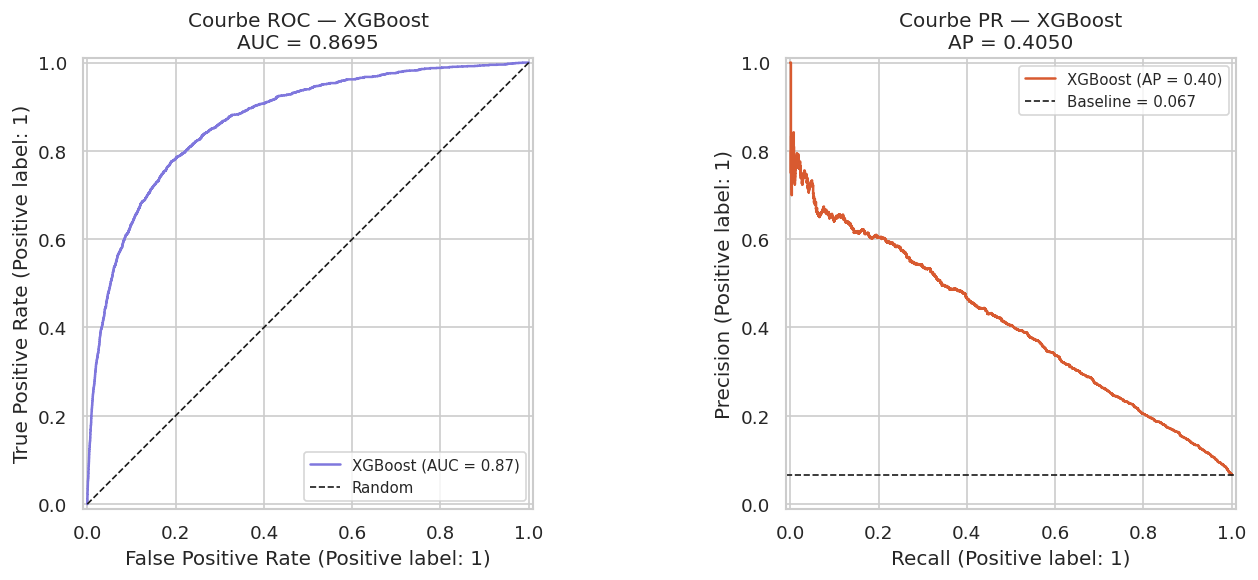

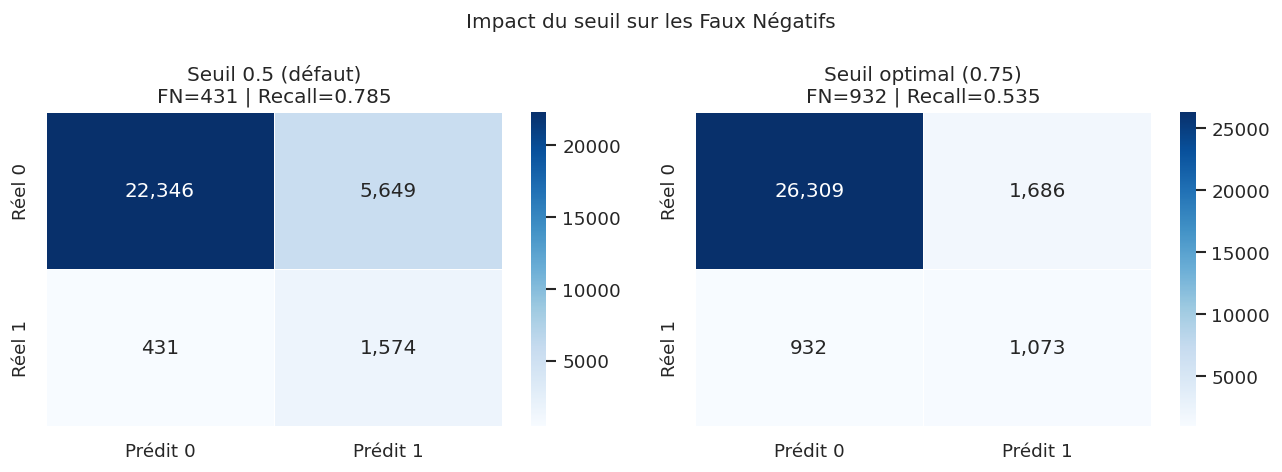


Modèle sauvegardé → /kaggle/working/models/final_model.pkl


In [9]:
# ============================================================
# ÉTAPE 3 — MODÈLE FINAL + ÉVALUATION SUR TEST SET
# ============================================================
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, RocCurveDisplay,
    PrecisionRecallDisplay, recall_score,
    precision_score, f1_score
)
import joblib, os

# Meilleur modèle → XGBoost
best_name  = "XGBoost"
best_model = models[best_name]
best_model.fit(X_train, y_train)
print(f"Modèle {best_name} fitté sur {X_train.shape[0]:,} observations")

# Prédictions
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred  = best_model.predict(X_test)

# Métriques de base
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc  = average_precision_score(y_test, y_proba)
print(f"\nROC-AUC (test) : {roc_auc:.4f}")
print(f"PR-AUC  (test) : {pr_auc:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Non-défaut','Défaut'])}")

# ── Seuil optimal ───────────────────────────────────────────
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores  = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1]+1e-9)
best_idx   = np.argmax(f1_scores)
best_thr   = thresholds[best_idx]
y_pred_opt = (y_proba >= best_thr).astype(int)

print(f"Seuil optimal   : {best_thr:.4f}")
print(f"Recall optimal  : {recall_score(y_test, y_pred_opt):.4f}")
print(f"Precision opt.  : {precision_score(y_test, y_pred_opt):.4f}")
print(f"F1 optimal      : {f1_score(y_test, y_pred_opt):.4f}")

# ── Courbes ROC et PR ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test, y_proba, name=best_name,
    ax=axes[0], color="#7F77DD"
)
axes[0].plot([0,1],[0,1],"k--",lw=1,label="Random")
axes[0].set_title(f"Courbe ROC — {best_name}\nAUC = {roc_auc:.4f}")
axes[0].legend(fontsize=9)

PrecisionRecallDisplay.from_predictions(
    y_test, y_proba, name=best_name,
    ax=axes[1], color="#D85A30"
)
axes[1].axhline(y=y_test.mean(), color="k", linestyle="--",
                lw=1, label=f"Baseline = {y_test.mean():.3f}")
axes[1].set_title(f"Courbe PR — {best_name}\nAP = {pr_auc:.4f}")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Matrice de confusion ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y_p, titre in zip(
    axes,
    [y_pred, y_pred_opt],
    [f"Seuil 0.5 (défaut)", f"Seuil optimal ({best_thr:.2f})"]
):
    cm = confusion_matrix(y_test, y_p)
    sns.heatmap(cm, annot=True, fmt=",", cmap="Blues",
                xticklabels=["Prédit 0","Prédit 1"],
                yticklabels=["Réel 0","Réel 1"],
                ax=ax, linewidths=0.5)
    tn,fp,fn,tp = cm.ravel()
    ax.set_title(f"{titre}\nFN={fn:,} | Recall={tp/(tp+fn):.3f}")
plt.suptitle("Impact du seuil sur les Faux Négatifs", fontsize=12)
plt.tight_layout()
plt.show()

# ── Sauvegarde ──────────────────────────────────────────────
os.makedirs("/kaggle/working/models", exist_ok=True)
joblib.dump(
    {"model": best_model, "threshold": best_thr},
    "/kaggle/working/models/final_model.pkl"
)
print(f"\nModèle sauvegardé → /kaggle/working/models/final_model.pkl")

In [10]:
# ============================================================
# ÉTAPE 4 — INTERPRÉTABILITÉ SHAP
# ============================================================
import shap

# Extraire le classifier et le preprocessor du pipeline
classifier          = best_model.named_steps["classifier"]
preprocessor_fitted = best_model.named_steps["preprocessor"]

# Transformer les données test
X_test_proc_df = pd.DataFrame(
    preprocessor_fitted.transform(X_test),
    columns=feature_names
)

# TreeExplainer → rapide et exact pour XGBoost
explainer   = shap.TreeExplainer(classifier)
shap_values = explainer(X_test_proc_df)

print(f"SHAP values calculated")
print(f"Shape : {shap_values.shape}")
print(f"→ {shap_values.shape[0]:,} clients × {shap_values.shape[1]} features")

SHAP values calculated
Shape : (30000, 10)
→ 30,000 clients × 10 features


Feature Importance Globale (SHAP) :


,feature,importance
0,RevolvingUtilizationOfUnsecuredLines,0.840108
1,NumberOfTime30-59DaysPastDueNotWorse,0.379136
2,NumberOfTimes90DaysLate,0.319045
3,age,0.232033
4,NumberOfTime60-89DaysPastDueNotWorse,0.175171
5,NumberOfOpenCreditLinesAndLoans,0.159681
6,DebtRatio,0.129059
7,NumberRealEstateLoansOrLines,0.111696
8,MonthlyIncome,0.098813
9,NumberOfDependents,0.022388


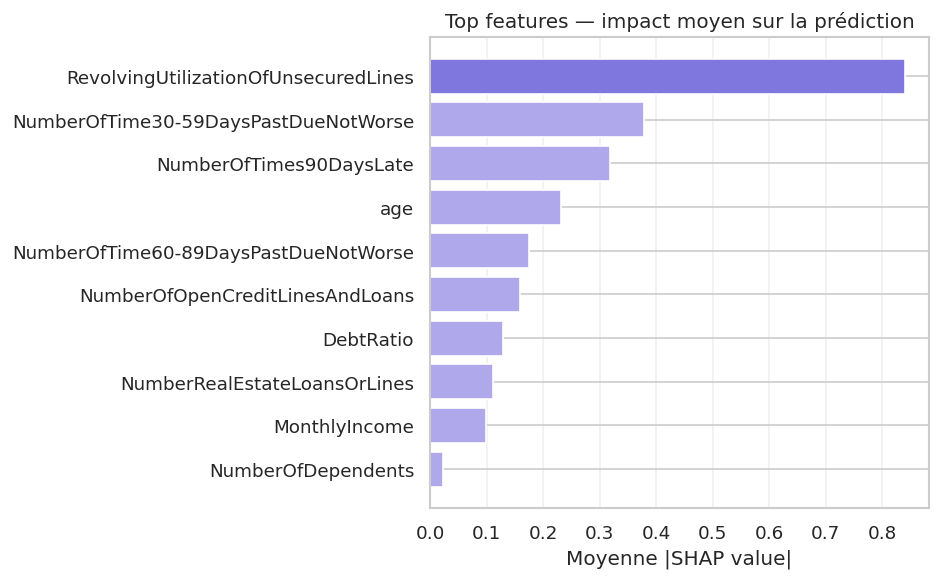

In [11]:
# ============================================================
# SHAP — FEATURE IMPORTANCE GLOBALE (Bar Plot)
# ============================================================
# Moyenne des |SHAP values| sur tout le test set
# → Quelle feature influence le plus les prédictions en moyenne ?

mean_abs_shap = pd.DataFrame({
    "feature"   : feature_names,
    "importance": np.abs(shap_values.values).mean(axis=0)
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Feature Importance Globale (SHAP) :")
display(mean_abs_shap)

# Visualisation
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#7F77DD" if i == 0 else "#AFA9EC"
          for i in range(len(mean_abs_shap))]
ax.barh(
    mean_abs_shap["feature"][::-1],
    mean_abs_shap["importance"][::-1],
    color=colors[::-1], edgecolor="white"
)
ax.set_xlabel("Moyenne |SHAP value|")
ax.set_title("Top features — impact moyen sur la prédiction")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

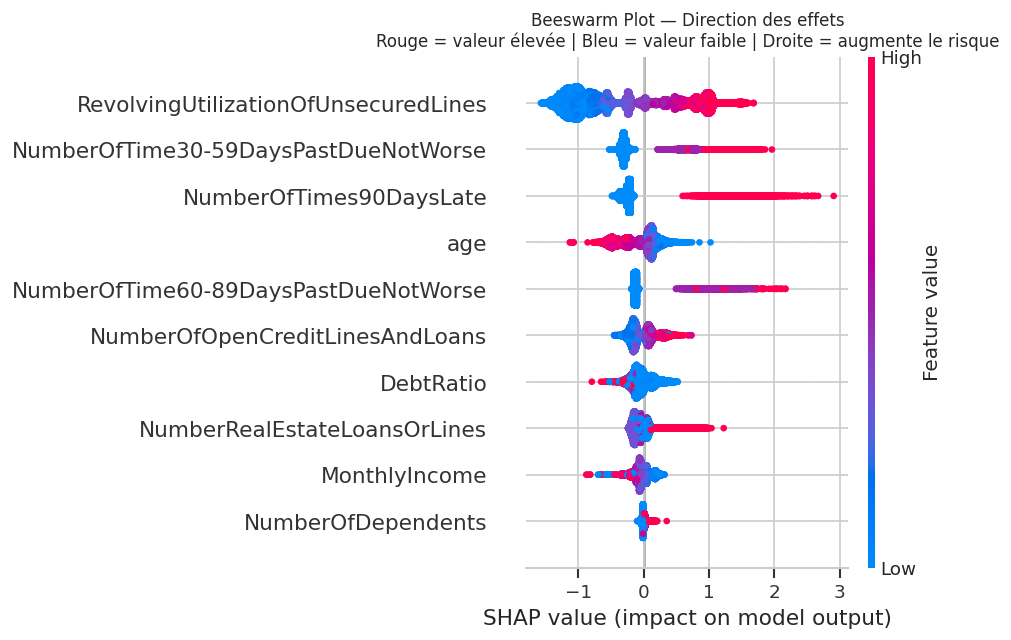

In [12]:
# ============================================================
# SHAP — BEESWARM PLOT
# ============================================================
# Montre COMMENT chaque feature influence les prédictions :
# → Position droite  = augmente le risque de défaut
# → Position gauche  = diminue le risque de défaut
# → Couleur rouge    = valeur élevée de la feature
# → Couleur bleue    = valeur faible de la feature

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title(
    "Beeswarm Plot — Direction des effets\n"
    "Rouge = valeur élevée | Bleu = valeur faible | "
    "Droite = augmente le risque",
    fontsize=10
)
plt.tight_layout()
plt.show()

Client analysé   : #7
Vrai label       : DÉFAUT (1)
Proba prédite    : 0.9645
Décision modèle  : REFUS

Profil du client :


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
12132,1.0,50,98,0.0,1350.0,0,98,0,98,0.0


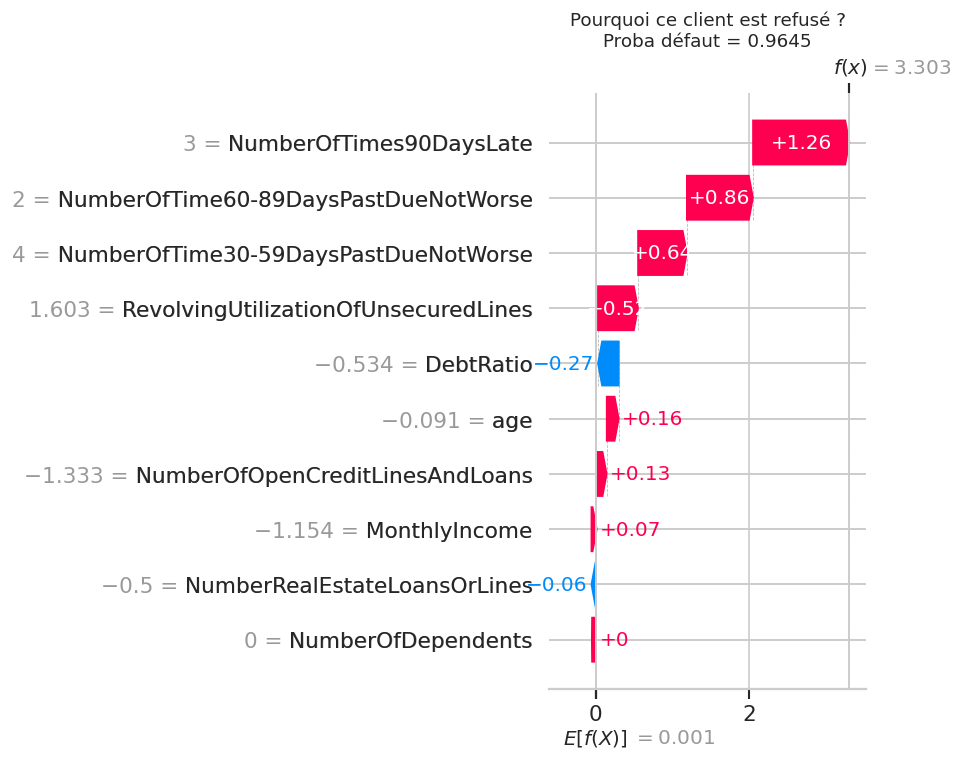

In [13]:
# ============================================================
# SHAP — WATERFALL PLOT (explication d'un client précis)
# ============================================================
# On choisit un vrai défaut pour l'expliquer

y_test_reset  = y_test.reset_index(drop=True)
vrais_defauts = y_test_reset[y_test_reset == 1].index
idx_client = vrais_defauts[0]

# Infos sur ce client
proba = best_model.predict_proba(X_test.iloc[[idx_client]])[0, 1]
print(f"Client analysé   : #{idx_client}")
print(f"Vrai label       : DÉFAUT (1)")
print(f"Proba prédite    : {proba:.4f}")
print(f"Décision modèle  : {'REFUS' if proba >= 0.5 else 'ACCORD'}")
print(f"\nProfil du client :")
display(X_test.iloc[[idx_client]])

# Waterfall plot
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[idx_client], show=False)
plt.title(
    f"Pourquoi ce client est refusé ?\n"
    f"Proba défaut = {proba:.4f}",
    fontsize=11
)
plt.tight_layout()
plt.show()


In [14]:
# ============================================================
# CONCLUSION & SAUVEGARDE FINALE
# ============================================================
import joblib, os

os.makedirs("/kaggle/working/models", exist_ok=True)
joblib.dump(
    {"model": best_model, "threshold": 0.5},
    "/kaggle/working/models/final_model.pkl"
)

print("=" * 55)
print("RÉSULTATS FINAUX — Credit Scoring Pipeline")
print("=" * 55)
print(f"Meilleur modèle  : XGBoost")
print(f"ROC-AUC (CV)     : 0.8644 ± 0.0035")
print(f"ROC-AUC (test)   : 0.8695")
print(f"Recall  (test)   : 0.785  → détecte 78.5% des défauts")
print(f"Seuil retenu     : 0.50")
print("=" * 55)
print("\nTop 3 features (SHAP) :")
print("  1. RevolvingUtilizationOfUnsecuredLines (0.840)")
print("  2. NumberOfTime30-59DaysPastDueNotWorse (0.379)")
print("  3. NumberOfTimes90DaysLate              (0.319)")
print("=" * 55)
print("\nModèle sauvegardé → /kaggle/working/models/final_model.pkl")

RÉSULTATS FINAUX — Credit Scoring Pipeline
Meilleur modèle  : XGBoost
ROC-AUC (CV)     : 0.8644 ± 0.0035
ROC-AUC (test)   : 0.8695
Recall  (test)   : 0.785  → détecte 78.5% des défauts
Seuil retenu     : 0.50

Top 3 features (SHAP) :
  1. RevolvingUtilizationOfUnsecuredLines (0.840)
  2. NumberOfTime30-59DaysPastDueNotWorse (0.379)
  3. NumberOfTimes90DaysLate              (0.319)

Modèle sauvegardé → /kaggle/working/models/final_model.pkl
